# 位置情報データチェックと気象データ取得準備
- ジャパンアグリのデータ
- 作物はレタス

In [1]:
import os
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon
import ast
import matplotlib.pyplot as plt

In [2]:
#--変数設定
farm_dir = 'farm'
farm_excel = '【confidential】サンプルデータ　ジャパンアグリ様②.xlsx'
excel_sheet = 'Sheet1'
farm_file = 'jpagri_farm.csv'
gpkg_file = 'jpagri_farm.gpkg'
gpkg_layer = 'jpagri_farm'

## 農場テーブル作成
- 圃場名とポリゴン情報は1対1に対応
- Excelファイルの「トップリバー様」と「トップリバー様（NDVI）」は圃場数が一致しない
    - 「トップリバー様（NDVI）」から農場テーブルを作成する

In [3]:
#--Excelファイル読み込み
df_org = pd.read_excel(f'{farm_dir}/{farm_excel}', sheet_name=excel_sheet)
df_org.dropna(inplace=True)
df_org.head()

,栽培グループ名,年度,圃場名,polygon,定植日,収穫日,経過日,NDVI値
0,春レタス（アイスクル）,2022,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...",2022-03-12 00:00:00,2022-05-09 00:00:00,1,0.000000
1,春レタス（アイスクル）,2022,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...",2022-03-12 00:00:00,2022-05-09 00:00:00,6,0.000000
2,春レタス（アイスクル）,2022,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...",2022-03-12 00:00:00,2022-05-09 00:00:00,11,0.000000
3,春レタス（アイスクル）,2022,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...",2022-03-12 00:00:00,2022-05-09 00:00:00,16,0.193220
4,春レタス（アイスクル）,2022,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...",2022-03-12 00:00:00,2022-05-09 00:00:00,21,0.225981


In [4]:
#--圃場名とポリゴンがユニークか確認
print("圃場名とポリゴンで重複を削除", df_org.drop_duplicates(subset=['圃場名','polygon']).shape )
print("圃場名のユニーク数", len(df_org['圃場名'].unique()) )
print("ポリゴンのユニーク数", len(df_org['polygon'].unique()) )

圃場名とポリゴンで重複を削除 (51, 8)
圃場名のユニーク数 51
ポリゴンのユニーク数 51


In [6]:
#--農場データフレーム作成
colnames = ['栽培グループ名', '圃場名', 'polygon']
df_farm = df_org[colnames].drop_duplicates(subset=['圃場名','polygon']).reset_index(drop=True)
# df_farm.to_csv(f"{farm_dir}/{farm_file}", index=False)

In [ ]:
# def convert_to_polygon(geom_str):
#     coords_list = ast.literal_eval(geom_str)  # 文字列をリストに safely 変換
#     return Polygon(coords_list)  # 最外周の1つ目のリング（穴がなければこれだけでOK）

# # ast.literal_eval は安全に文字列 → Pythonリストに変換できます（evalは使わないでください）。
# # ポリゴンの穴（内側リング）がある場合は Polygon(outer_ring, [hole1, hole2, ...]) のように加工が必要です。

# df["geometry"] = df["polygon"].apply(convert_to_polygon)
# df.head()

In [7]:
#--ポリゴンのテキスト情報を地理情報フォーマットに変換
def make_polygon(geom_str):
    coords_latlon = ast.literal_eval(geom_str)
    #--lat,lon の順番を、lon,latに変える
    coords_lonlat = [(lon, lat) for lat, lon in coords_latlon]
    return Polygon(coords_lonlat)

df_farm["geometry"] = df_farm["polygon"].apply(make_polygon)
df_farm.head()

,栽培グループ名,圃場名,polygon,geometry
0,春レタス（アイスクル）,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...","POLYGON ((139.883291 36.200606, 139.883246 36...."
1,春レタス（アイスクル）,幸田２ 1.00a,"[[36.2029786, 139.8780847], [36.2027318, 139.8...","POLYGON ((139.8780847 36.2029786, 139.8783529 ..."
2,春レタス（アイスクル）,トモコ畑 29ａ,"[[36.20289934577446, 139.8792026413102], [36.2...","POLYGON ((139.8792026413102 36.20289934577446,..."
3,春レタス（アイスクル）,先生脇 33.37a,"[[36.202948, 139.879867], [36.202897, 139.8792...","POLYGON ((139.879867 36.202948, 139.879261 36...."
4,春レタス（アイスクル）,農北 20.08a,"[[36.202979, 139.876883], [36.202654, 139.8771...","POLYGON ((139.876883 36.202979, 139.877127 36...."


In [8]:
#--GeoDataFrameに変換
gdf_farm = gpd.GeoDataFrame(df_farm, geometry="geometry", crs="EPSG:4326")
gdf_farm.head()

,栽培グループ名,圃場名,polygon,geometry
0,春レタス（アイスクル）,浜前 20.64a,"[[36.200606, 139.883291], [36.200167, 139.8832...","POLYGON ((139.88329 36.20061, 139.88325 36.200..."
1,春レタス（アイスクル）,幸田２ 1.00a,"[[36.2029786, 139.8780847], [36.2027318, 139.8...","POLYGON ((139.87808 36.20298, 139.87835 36.202..."
2,春レタス（アイスクル）,トモコ畑 29ａ,"[[36.20289934577446, 139.8792026413102], [36.2...","POLYGON ((139.8792 36.2029, 139.87923 36.20261..."
3,春レタス（アイスクル）,先生脇 33.37a,"[[36.202948, 139.879867], [36.202897, 139.8792...","POLYGON ((139.87987 36.20295, 139.87926 36.202..."
4,春レタス（アイスクル）,農北 20.08a,"[[36.202979, 139.876883], [36.202654, 139.8771...","POLYGON ((139.87688 36.20298, 139.87713 36.202..."


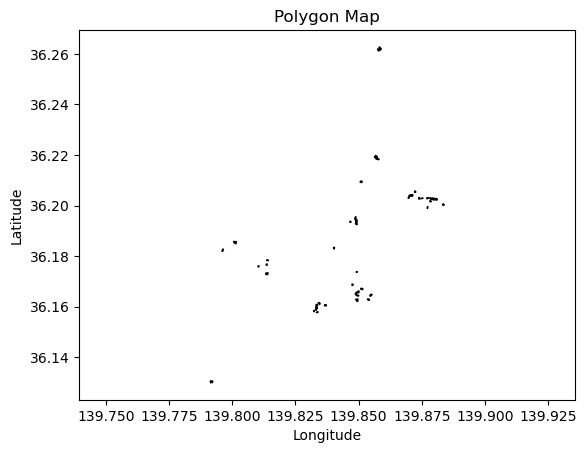

In [9]:
#--可視化を試す
gdf_farm.plot(edgecolor='black', facecolor='lightblue')
plt.title("Polygon Map")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.axis('equal') # スケールを揃える
plt.show()

In [10]:
#--GeoPackage形式で出力
gdf_farm.to_file(f"{farm_dir}/{gpkg_file}", driver='GPKG', layer=gpkg_layer, encoding='utf-8')

In [11]:
#--各ポリゴンの重心位置を計算
latitude = []
longitude = []
for i, row in gdf_farm.iterrows():
    center = list(row['geometry'].centroid.coords)[0]
    longitude.append(center[0])
    latitude.append(center[1])

gdf_farm["longitude"] = longitude
gdf_farm["latitude"] = latitude

In [12]:
#--便宜上、圃場ごとの固有IDをつける
gdf_farm['field_id'] = ["jpagri" + str(i).zfill(2) for i in range(len(gdf_farm))]

#--緯度経度情報を含めてCSV出力
col_order = ['field_id', '栽培グループ名', '圃場名', 'longitude', 'latitude', 'polygon']
gdf_farm[col_order].to_csv(f"{farm_dir}/{farm_file}", index=False)